# **#** Deepfake Image Detection — EfficientNet + Dlib + SVM

---

## → Step 1: Install Required Libraries

In [6]:
print(" Installing required libraries...")

!pip install -q timm facenet-pytorch kaggle dlib

print(" Libraries installed successfully!")

 Installing required libraries...
 Libraries installed successfully!


#iske baad session ko restart kro

In [1]:
import numpy as np
import cv2
import dlib
import timm
import torch
from PIL import Image

print(np.__version__)
print("All imports working!")

1.26.4
All imports working!


## → Step 2: Import Required Libraries

In [2]:
print(" Importing all required modules...")

import os
import random
import glob
import numpy as np
import cv2
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from tqdm import tqdm
from PIL import Image

import timm  # EfficientNet lives here
import dlib

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import LinearSVC
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print(" All modules imported successfully!")

 Importing all required modules...
 All modules imported successfully!


## → Step 3: Setup Kaggle API & Download Dataset

In [3]:
print(" Setting up Kaggle API credentials...\n")
from google.colab import files

files.upload()  # Upload your kaggle.json here

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print(" Kaggle credentials configured!\n")

print(" Downloading 140k Real vs Fake Faces dataset from Kaggle...")
!kaggle datasets download -d xhlulu/140k-real-and-fake-faces
print(" Download complete! Unzipping...\n")

!unzip -q 140k-real-and-fake-faces.zip
print(" Dataset extracted successfully!")

 Setting up Kaggle API credentials...



Saving kaggle.json to kaggle.json
 Kaggle credentials configured!

Dataset URL: https://www.kaggle.com/datasets/xhlulu/140k-real-and-fake-faces
License(s): other
100% 3.75G/3.75G [00:19<00:00, 210MB/s]

 Download complete! Unzipping...

 Dataset extracted successfully!


## → Step 4: Explore & Verify Dataset

In [4]:
print(" Scanning dataset directories...")

input_root = "real_vs_fake/real-vs-fake/train"

real_files = [f for f in os.listdir(os.path.join(input_root, 'real'))
              if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
fake_files = [f for f in os.listdir(os.path.join(input_root, 'fake'))
              if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

print(f" Number of REAL images : {len(real_files)}")
print(f" Number of FAKE images : {len(fake_files)}")
print(f" Total images          : {len(real_files) + len(fake_files)}")
print(" Dataset verified!")

 Scanning dataset directories...
 Number of REAL images : 50000
 Number of FAKE images : 50000
 Total images          : 100000
 Dataset verified!


 Displaying sample images...



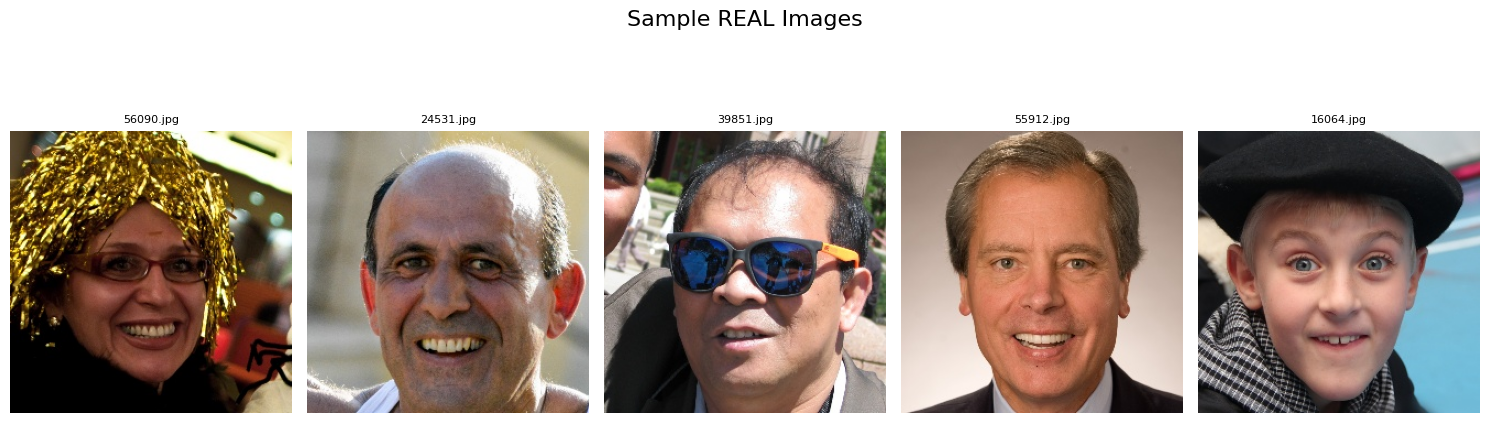

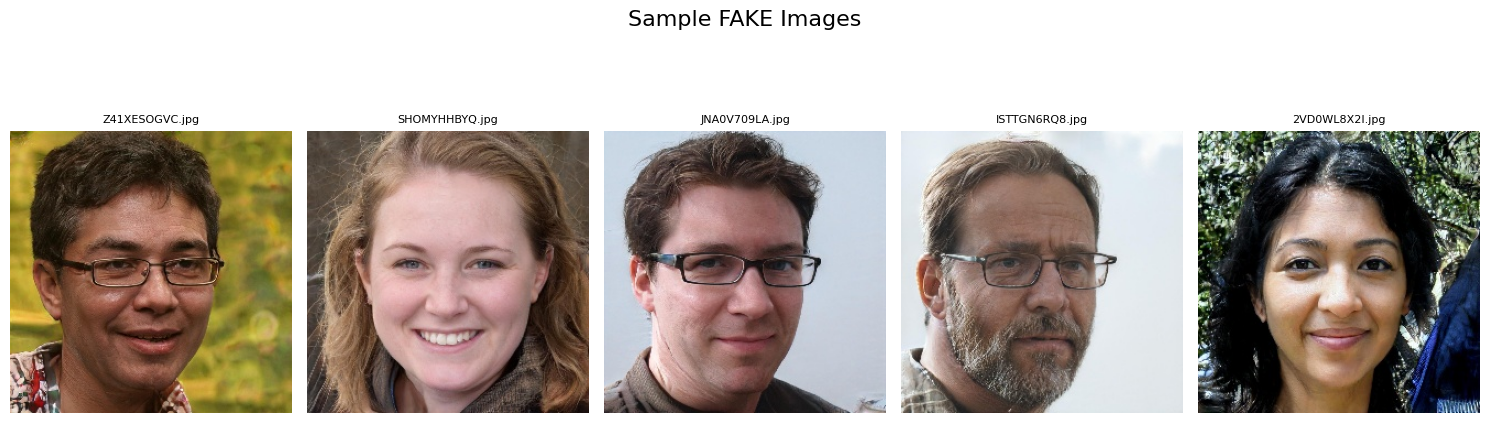


 Sample images displayed!


In [5]:
print(" Displaying sample images...\n")

def display_sample_images(image_list, directory, title, num_samples=5):
    plt.figure(figsize=(15, 5))
    plt.suptitle(title, fontsize=16)
    for i in range(min(num_samples, len(image_list))):
        image_name = random.choice(image_list)
        image_path = os.path.join(directory, image_name)
        try:
            img = Image.open(image_path)
            plt.subplot(1, num_samples, i + 1)
            plt.imshow(img)
            plt.title(image_name, fontsize=8)
            plt.axis('off')
        except Exception as e:
            print(f"   Error loading {image_path}: {e}")
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

display_sample_images(real_files, os.path.join(input_root, 'real'), "Sample REAL Images")
display_sample_images(fake_files, os.path.join(input_root, 'fake'), "Sample FAKE Images")
print("\n Sample images displayed!")

## → Step 5: Load EfficientNet-B4 Feature Extractor


In [6]:
print(" Setting up compute device...")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" Using device: {device}")
if device.type == 'cuda':
    print(f" GPU: {torch.cuda.get_device_name(0)}")

print("\n Loading EfficientNet-B4 pretrained on ImageNet...")
# EfficientNet-B4 via timm — pretrained on ImageNet-1k
efficientnet = timm.create_model('efficientnet_b4', pretrained=True, num_classes=0)  # num_classes=0 → feature extractor
efficientnet = efficientnet.to(device)
efficientnet.eval()

print(f" EfficientNet-B4 loaded! Output feature dim: {efficientnet.num_features}")


 Setting up compute device...
 Using device: cuda
 GPU: Tesla T4

 Loading EfficientNet-B4 pretrained on ImageNet...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

 EfficientNet-B4 loaded! Output feature dim: 1792


## → Step 6: Download & Load Dlib Face Landmark Predictor

In [7]:
print(" Downloading Dlib 68-point face landmark model...")
!wget -q http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
!bunzip2 -f shape_predictor_68_face_landmarks.dat.bz2
print(" Dlib model downloaded and extracted!")

detector  = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor("shape_predictor_68_face_landmarks.dat")
print(" Dlib face detector and landmark predictor loaded!")

 Dlib model downloaded and extracted!
 Dlib face detector and landmark predictor loaded!


## → Step 7: Define Preprocessing Transforms


In [8]:
print(" Defining image preprocessing transforms...")
print(" EfficientNet-B4 native input: 380×380 ")
print(" Using ImageNet normalization stats")

# EfficientNet-B4 native resolution is 380x380
efficientnet_transform = transforms.Compose([
    transforms.Resize((380, 380)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print(" Transforms defined! (Resize→ToTensor→Normalize)")

 Defining image preprocessing transforms...
 EfficientNet-B4 native input: 380×380 
 Using ImageNet normalization stats
 Transforms defined! (Resize→ToTensor→Normalize)


## → Step 8: Define Feature Extraction Functions


In [9]:
print(" Defining facial landmark & dataset helper functions...")

# Facial region landmark indices
FACIAL_REGIONS = {
    "jaw"       : list(range(0, 17)),
    "nose"      : list(range(27, 36)),
    "left_eye"  : list(range(42, 48)),
    "right_eye" : list(range(36, 42)),
    "mouth"     : list(range(48, 68))
}

def extract_facial_landmark_features(img_path, min_face_size=30):
    """
    Extracts 136-dim normalized facial landmark features using Dlib.
    Returns zero vector if face detection fails or face is too small.
    """
    img = cv2.imread(img_path)
    if img is None:
        return np.zeros(136, dtype=np.float32)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    # upscale small images to improve detection
    faces = detector(gray, 1)

    if len(faces) == 0:
        return np.zeros(136, dtype=np.float32)

    # Select the largest face (most prominent)
    face = max(faces, key=lambda r: r.width() * r.height())

    # skip faces that are too small (likely noise)
    if face.width() < min_face_size or face.height() < min_face_size:
        return np.zeros(136, dtype=np.float32)

    landmarks = predictor(gray, face)
    h, w = gray.shape

    features = []
    for region in FACIAL_REGIONS.values():
        for i in region:
            # Normalize by image dimensions
            x = landmarks.part(i).x / w
            y = landmarks.part(i).y / h
            features.extend([x, y])

    return np.array(features, dtype=np.float32)


class ImageFolderWithPaths(Dataset):
    """Dataset class returning (image_tensor, label, full_path)."""
    def __init__(self, root_dir, label_idx, transform):
        self.paths = [
            os.path.join(root_dir, f)
            for f in os.listdir(root_dir)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ]
        self.label_idx = label_idx
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        return self.transform(img), self.label_idx, self.paths[idx]


print(" Landmark extractor and Dataset class ready!")
print(f" Landmark feature dimension: 136")

 Defining facial landmark & dataset helper functions...
 Landmark extractor and Dataset class ready!
 Landmark feature dimension: 136


## → Step 9: Build DataLoaders

In [10]:
print(" Building datasets and DataLoaders...")

input_root = 'real_vs_fake/real-vs-fake/train'
BATCH_SIZE = 64  # Reduced slightly for 380x380 images — increase if you have GPU memory

real_dataset = ImageFolderWithPaths(
    os.path.join(input_root, 'real'), label_idx=0, transform=efficientnet_transform
)
fake_dataset = ImageFolderWithPaths(
    os.path.join(input_root, 'fake'), label_idx=1, transform=efficientnet_transform
)

combined_dataset = torch.utils.data.ConcatDataset([real_dataset, fake_dataset])
loader = DataLoader(
    combined_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True if device.type == 'cuda' else False
)

print(f" DataLoaders ready!")
print(f" Real images  : {len(real_dataset)}")
print(f" Fake images  : {len(fake_dataset)}")
print(f" Total batches: {len(loader)} (batch size={BATCH_SIZE})")

 Building datasets and DataLoaders...
 DataLoaders ready!
 Real images  : 50000
 Fake images  : 50000
 Total batches: 1563 (batch size=64)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


## → Step 10: Extract Features (EfficientNet-B4 + Dlib Landmarks)


In [11]:
print(" Starting feature extraction — EfficientNet-B4 + Dlib Landmarks...")
print(f" EfficientNet-B4 features : 1792-dim")
print(f" Dlib landmark features   : 136-dim")
print(f" Combined feature vector  : 1928-dim")
print(f" This will process {len(combined_dataset)} images. Please wait...\n")

batch_idx = 0
feature_files = []
label_files   = []
failed_batches = 0

with torch.no_grad():
    for imgs, labels, filenames in tqdm(loader, desc="🔍 Extracting Features"):
        try:
            # ── EfficientNet-B4 deep features ──────────────────────────────
            imgs = imgs.to(device)
            deep_feats = efficientnet(imgs)         # (B, 1792)
            deep_feats = deep_feats.cpu().numpy()

            # ── Dlib facial landmark features ──────────────────────────────
            landmark_feats = []
            for fpath in filenames:
                lf = extract_facial_landmark_features(fpath)
                if lf is None or lf.shape[0] != 136:
                    lf = np.zeros(136, dtype=np.float32)
                landmark_feats.append(lf)
            landmark_feats = np.stack(landmark_feats)  # (B, 136)

            # ── Combine ────────────────────────────────────────────────────
            combined_feats  = np.hstack([deep_feats, landmark_feats])  # (B, 1928)
            combined_labels = labels.numpy()

            # ── Save batch to disk ─────────────────────────────────────────
            feat_file  = f"batch_features_{batch_idx}.npy"
            label_file = f"batch_labels_{batch_idx}.npy"
            np.save(feat_file,  combined_feats)
            np.save(label_file, combined_labels)
            feature_files.append(feat_file)
            label_files.append(label_file)

            del imgs, deep_feats, landmark_feats
            batch_idx += 1

        except Exception as e:
            print(f"  Skipping batch {batch_idx} due to error: {e}")
            failed_batches += 1
            batch_idx += 1

print(f"\n Feature extraction complete!")
print(f" Saved : {len(feature_files)} batches")
print(f" Failed: {failed_batches} batches (errors)")

 Starting feature extraction — EfficientNet-B4 + Dlib Landmarks...
 EfficientNet-B4 features : 1792-dim
 Dlib landmark features   : 136-dim
 Combined feature vector  : 1928-dim
 This will process 100000 images. Please wait...



🔍 Extracting Features: 100%|██████████| 1563/1563 [1:21:26<00:00,  3.13s/it]


 Feature extraction complete!
 Saved : 1563 batches
 Failed: 0 batches (errors)


## → Step 11: Consolidate & Save All Features

In [12]:
print(" Consolidating all batch features into single arrays...")

feature_files = sorted(glob.glob("batch_features_*.npy"))
label_files   = sorted(glob.glob("batch_labels_*.npy"))

print(f"  Loading {len(feature_files)} feature batches...")
X = np.vstack([np.load(f) for f in feature_files])
y = np.hstack([np.load(f) for f in label_files])

print(f"  Feature matrix shape : {X.shape}")
print(f"  Label vector shape   : {y.shape}")
print(f"  Class distribution   — Real: {(y==0).sum()}, Fake: {(y==1).sum()}")

np.save("features_efficientnet_b4_dlib.npy", X)
np.save("labels_efficientnet_b4_dlib.npy",   y)

print(" Saved: features_efficientnet_b4_dlib.npy & labels_efficientnet_b4_dlib.npy")

 Consolidating all batch features into single arrays...
  Loading 1563 feature batches...
  Feature matrix shape : (100000, 1928)
  Label vector shape   : (100000,)
  Class distribution   — Real: 50000, Fake: 50000
 Saved: features_efficientnet_b4_dlib.npy & labels_efficientnet_b4_dlib.npy


## → Step 12: Train-Test Split

In [13]:
print(" Loading features and splitting into train/test sets...")

X = np.load("features_efficientnet_b4_dlib.npy")
y = np.load("labels_efficientnet_b4_dlib.npy")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f" Split complete!")
print(f"  Train size : {X_train.shape[0]} samples")
print(f"  Test  size : {X_test.shape[0]} samples")
print(f"  Feature dim: {X_train.shape[1]}")

 Loading features and splitting into train/test sets...
 Split complete!
  Train size : 80000 samples
  Test  size : 20000 samples
  Feature dim: 1928


## → Step 13: Feature Scaling

In [14]:
print(" Applying separate StandardScalers for deep & landmark features...")
print("  Separate scaling avoids deep features dominating landmark features")

DEEP_DIM = 1792   # EfficientNet-B4 output
LAND_DIM = 136    # Dlib 68-point landmarks

# Split feature blocks
deep_train, land_train = X_train[:, :DEEP_DIM], X_train[:, DEEP_DIM:]
deep_test,  land_test  = X_test[:,  :DEEP_DIM], X_test[:,  DEEP_DIM:]

# Scale each block independently
deep_scaler = StandardScaler()
deep_train  = deep_scaler.fit_transform(deep_train)
deep_test   = deep_scaler.transform(deep_test)
print(" Deep feature scaler fitted and applied")

land_scaler = StandardScaler()
land_train  = land_scaler.fit_transform(land_train)
land_test   = land_scaler.transform(land_test)
print(" Landmark feature scaler fitted and applied")

# Recombine
X_train = np.hstack((deep_train, land_train))
X_test  = np.hstack((deep_test,  land_test))

print(f" Scaling complete! Final feature shape: {X_train.shape}")

 Applying separate StandardScalers for deep & landmark features...
  Separate scaling avoids deep features dominating landmark features
 Deep feature scaler fitted and applied
 Landmark feature scaler fitted and applied
 Scaling complete! Final feature shape: (80000, 1928)


## → Step 14: Applying PCA


In [15]:
print(" Applying PCA for dimensionality reduction...")
#print("    Retaining 99% variance ")
print("    Reducing to 128 dimensions for multimodal fusion ")

pca = PCA(n_components=128, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca  = pca.transform(X_test)

print(f" PCA complete!")
print(f"   Original dim  : {X_train.shape[1]}")
print(f"   Reduced dim   : {X_train_pca.shape[1]}")
#print(f"   Reduced dim   : {X_train_pca.shape[1]} (99% variance retained)")
#print(f"   Variance kept : {pca.explained_variance_ratio_.sum()*100:.2f}%")

# ================================
# SAVE IMAGE EMBEDDINGS FOR FUSION
# ================================

print("\n Saving image embedding vectors for multimodal fusion...")

np.save("image_vectors_train.npy", X_train_pca)
np.save("image_vectors_test.npy",  X_test_pca)

np.save("image_labels_train.npy", y_train)
np.save("image_labels_test.npy",  y_test)

print(" Image vectors saved successfully!")

print(f" Train vectors shape : {X_train_pca.shape}")
print(f" Test vectors shape  : {X_test_pca.shape}")

 Applying PCA for dimensionality reduction...
    Reducing to 128 dimensions for multimodal fusion 
 PCA complete!
   Original dim  : 1928
   Reduced dim   : 128

 Saving image embedding vectors for multimodal fusion...
 Image vectors saved successfully!
 Train vectors shape : (80000, 128)
 Test vectors shape  : (20000, 128)


In [16]:
print(X_train_pca.shape)
print(X_test_pca.shape)
print(y_train.shape)
print(y_test.shape)

(80000, 128)
(20000, 128)
(80000,)
(20000,)


In [17]:
# ================================
# DOWNLOAD IMAGE EMBEDDINGS
# ================================

from google.colab import files

files.download("image_vectors_train.npy")
files.download("image_vectors_test.npy")

files.download("image_labels_train.npy")
files.download("image_labels_test.npy")

print(" All embedding files downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 All embedding files downloaded!


## → Step 15: Train LinearSVC Classifier


In [18]:
print(" Training LinearSVC on PCA-reduced EfficientNet + Landmark features...")
print("    LinearSVC is fast and works great with high-dim feature vectors")
print(f" Training on {X_train_pca.shape[0]} samples with {X_train_pca.shape[1]} features...")

svm_model = LinearSVC(
    C=0.5,
    max_iter=10000,
    dual=False,              # Faster when n_samples >> n_features
    class_weight='balanced', # Handles class imbalance
    random_state=42
)

svm_model.fit(X_train_pca, y_train)

print(" SVM training complete!")

 Training LinearSVC on PCA-reduced EfficientNet + Landmark features...
    LinearSVC is fast and works great with high-dim feature vectors
 Training on 80000 samples with 128 features...
 SVM training complete!


## → Step 16: Evaluate Model — Accuracy, Report & Confusion Matrix

 Evaluating model on test set...

    Test Accuracy : 86.59%

 Classification Report:
              precision    recall  f1-score   support

        REAL       0.88      0.85      0.86     10000
        FAKE       0.86      0.88      0.87     10000

    accuracy                           0.87     20000
   macro avg       0.87      0.87      0.87     20000
weighted avg       0.87      0.87      0.87     20000



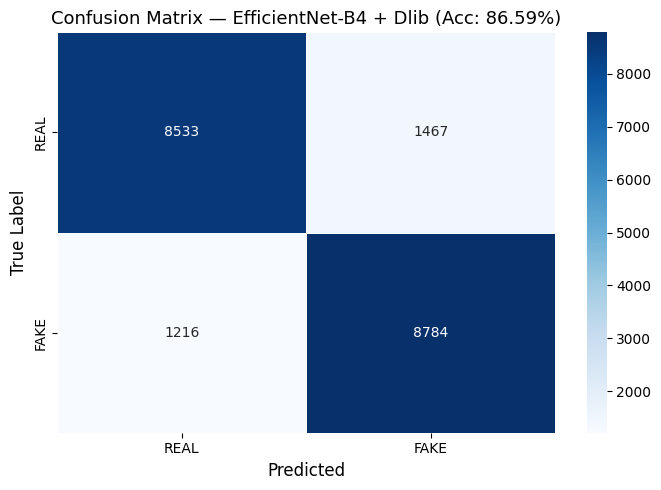


 Evaluation complete!


In [19]:
print(" Evaluating model on test set...")

y_pred = svm_model.predict(X_test_pca)
acc    = accuracy_score(y_test, y_pred)

print(f"\n{'='*55}")
print(f"    Test Accuracy : {acc*100:.2f}%")
print(f"{'='*55}")
print("\n Classification Report:")
print(classification_report(y_test, y_pred, target_names=['REAL', 'FAKE']))

# ── Confusion Matrix ───────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['REAL', 'FAKE'],
    yticklabels=['REAL', 'FAKE'],
    linewidths=0.5
)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title(f'Confusion Matrix — EfficientNet-B4 + Dlib (Acc: {acc*100:.2f}%)', fontsize=13)
plt.tight_layout()
plt.show()

print("\n Evaluation complete!")

## ✅ Step 17: Save Model, Scalers & PCA

In [23]:
print("[STEP 17] Saving trained model, scalers, and PCA to disk...")

joblib.dump(svm_model,    'svm_efficientnet_b4.pkl')
joblib.dump(deep_scaler,  'deep_scaler.pkl')
joblib.dump(land_scaler,  'land_scaler.pkl')
joblib.dump(pca,          'pca_efficientnet_b4.pkl')

print("[STEP 17] Saved:")
print("[STEP 17]   svm_efficientnet_b4.pkl  — SVM classifier")
print("[STEP 17]   deep_scaler.pkl          — EfficientNet feature scaler")
print("[STEP 17]   land_scaler.pkl          — Landmark feature scaler")
print("[STEP 17]   pca_efficientnet_b4.pkl  — PCA transform")

[STEP 17] Saving trained model, scalers, and PCA to disk...
[STEP 17] Saved:
[STEP 17]   svm_efficientnet_b4.pkl  — SVM classifier
[STEP 17]   deep_scaler.pkl          — EfficientNet feature scaler
[STEP 17]   land_scaler.pkl          — Landmark feature scaler
[STEP 17]   pca_efficientnet_b4.pkl  — PCA transform


In [24]:
print("[STEP 17b] Downloading saved model files...")

from google.colab import files

files.download('svm_efficientnet_b4.pkl')
files.download('deep_scaler.pkl')
files.download('land_scaler.pkl')
files.download('pca_efficientnet_b4.pkl')

print("[STEP 17b] All files downloaded!")

[STEP 17b] Downloading saved model files...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

[STEP 17b] All files downloaded!


## ✅ Step 18: Single Image Prediction

[STEP 18] Setting up prediction pipeline for a new image...
[STEP 18] All components loaded for prediction!

[STEP 18B] Upload an image to test the detector:


Saving Screenshot 2026-05-20 112539.png to Screenshot 2026-05-20 112539.png

Analyzing: Screenshot 2026-05-20 112539.png
→ Extracting EfficientNet-B4 deep features...
→ Scaling features...
→ Applying PCA transformation...
→ Running SVM classifier...
→ Confidence Score: 0.7700


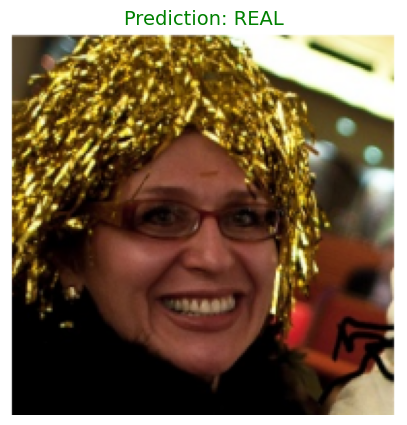


[FINAL RESULT]
Prediction : REAL
Confidence : 0.7700


In [38]:
print("[STEP 18] Setting up prediction pipeline for a new image...")

# ── Load saved assets ──────────────────────────────────────────────────────
svm_model   = joblib.load('svm_efficientnet_b4.pkl')
deep_scaler = joblib.load('deep_scaler.pkl')
land_scaler = joblib.load('land_scaler.pkl')
pca         = joblib.load('pca_efficientnet_b4.pkl')

# ── Reload model (in case kernel was restarted) ────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

efficientnet = timm.create_model(
    'efficientnet_b4',
    pretrained=True,
    num_classes=0
).to(device)

efficientnet.eval()

transform = transforms.Compose([
    transforms.Resize((380, 380)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("[STEP 18] All components loaded for prediction!")


# ────────────────────────────────────────────────────────────────────────────
# Prediction Function
# ────────────────────────────────────────────────────────────────────────────

def predict_deepfake(img_path):
    """
    Predict whether an image is REAL or FAKE
    using EfficientNet-B4 + Dlib + PCA + SVM
    """

    print(f"\nAnalyzing: {os.path.basename(img_path)}")

    # ── Step A: Deep Features ──────────────────────────────────────────────
    print("→ Extracting EfficientNet-B4 deep features...")

    img = Image.open(img_path).convert('RGB')

    tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        deep_feats = efficientnet(tensor).cpu().numpy()   # (1,1792)

    # ── Step B: Landmark Features ──────────────────────────────────────────
    land_feats = extract_facial_landmark_features(img_path)

    # Ensure fixed 136-d landmark vector
    if len(land_feats) < 136:

         padded = np.zeros(136)

         padded[:len(land_feats)] = land_feats

         land_feats = padded

    elif len(land_feats) > 136:

         land_feats = land_feats[:136]

    land_feats = land_feats.reshape(1, -1)

    # ── Step C: Independent Scaling ────────────────────────────────────────
    print("→ Scaling features...")

    deep_scaled = deep_scaler.transform(deep_feats)
    land_scaled = land_scaler.transform(land_feats)

    # ── Step D: Combine + PCA ──────────────────────────────────────────────
    print("→ Applying PCA transformation...")

    combined = np.hstack((deep_scaled, land_scaled))

    combined_pca = pca.transform(combined)   # (1,128)

    # ── Step E: SVM Prediction ─────────────────────────────────────────────
    print("→ Running SVM classifier...")

    score = svm_model.decision_function(combined_pca)[0]

    pred = svm_model.predict(combined_pca)[0]

    label = "REAL" if pred == 0 else "FAKE"

    confidence = abs(score)

    print(f"→ Confidence Score: {confidence:.4f}")

    # ── Display Image ──────────────────────────────────────────────────────
    plt.figure(figsize=(5,5))

    plt.imshow(img)

    plt.title(
        f"Prediction: {label}",
        fontsize=14,
        color='green' if pred == 0 else 'red'
    )

    plt.axis('off')

    plt.show()

    return label, confidence


# ────────────────────────────────────────────────────────────────────────────
# Upload & Predict
# ────────────────────────────────────────────────────────────────────────────

print("\n[STEP 18B] Upload an image to test the detector:")

from google.colab import files

uploaded = files.upload()

sample_image_path = list(uploaded.keys())[0]

label, confidence = predict_deepfake(sample_image_path)

print(f"\n[FINAL RESULT]")
print(f"Prediction : {label}")
print(f"Confidence : {confidence:.4f}")